# 14.3案例实战 - 电影智能推荐系统

In [2]:
import pandas as pd 
movies = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第14章 智能推荐系统\源代码汇总_Jupyter Notebook格式（推荐）\电影.xlsx")
movies.head()

,电影编号,名称,类别
0,1,玩具总动员（1995）,冒险|动画|儿童|喜剧|幻想
1,2,勇敢者的游戏（1995）,冒险|儿童|幻想
2,3,斗气老顽童2（1995）,喜剧|爱情
3,4,待到梦醒时分（1995）,喜剧|剧情|爱情
4,5,新娘之父2（1995）,喜剧


In [4]:
score = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第14章 智能推荐系统\源代码汇总_Jupyter Notebook格式（推荐）\评分.xlsx")
score.head()

,用户编号,电影编号,评分
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [6]:
df = pd.merge(movies, score, on='电影编号') # 通过电影编号进行关联
df.head()

,电影编号,名称,类别,用户编号,评分
0,1,玩具总动员（1995）,冒险|动画|儿童|喜剧|幻想,1,4.0
1,1,玩具总动员（1995）,冒险|动画|儿童|喜剧|幻想,5,4.0
2,1,玩具总动员（1995）,冒险|动画|儿童|喜剧|幻想,7,4.5
3,1,玩具总动员（1995）,冒险|动画|儿童|喜剧|幻想,15,2.5
4,1,玩具总动员（1995）,冒险|动画|儿童|喜剧|幻想,17,4.5


In [8]:
df.to_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第14章 智能推荐系统\源代码汇总_Jupyter Notebook格式（推荐）\电影推荐系统.xlsx") 

In [10]:
df['评分'].value_counts()  # 查看各个评分的出现的次数

评分
4.0    26794
3.0    20017
5.0    13180
3.5    13129
4.5     8544
2.0     7545
2.5     5544
1.0     2808
1.5     1791
0.5     1369
Name: count, dtype: int64

<Axes: >

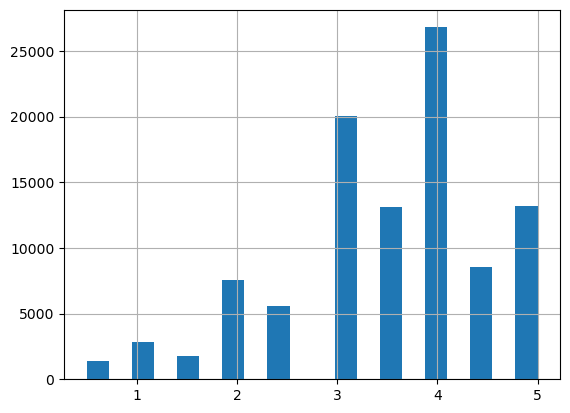

In [12]:
import matplotlib.pyplot as plt
df['评分'].hist(bins=20)  # hist()函数绘制直方图，竖轴为各评分出现的次数

In [14]:
ratings = pd.DataFrame(df.groupby('名称')['评分'].mean())
ratings.sort_values('评分', ascending=False).head()

,评分
名称,
假小子（1997）,5.0
福尔摩斯和华生医生历险记：讹诈之王（1980）,5.0
机器人（2016）,5.0
奥斯卡（1967）,5.0
人类状况III（1961）,5.0


In [16]:
user_movie = df.pivot_table(index='用户编号', columns='名称', values='评分')
user_movie.tail()

名称,007之黄金眼（1995）,100个女孩（2000）,100条街道（2016）,101忠狗续集:伦敦大冒险（2003）,101忠狗（1961）,101雷克雅未克（2000）,102只斑点狗（2000）,10件或更少（2006）,10（1979）,11:14（2003）,...,龙珠：神秘冒险（1988）,龙珠：血红宝石的诅咒（1986）,龙珠：魔鬼城堡中的睡公主（1987）,龙种子（1944）,龙纹身的女孩（2011）,龙舌兰日出（1988）,龙虾（2015）,龙：夜之怒的礼物（2011）,龙：李小龙的故事（1993）,龟日记（1985）
用户编号,,,,,,,,,,,,,,,,,,,,,
606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
608,4.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
609,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN


In [18]:
user_movie.describe()  # 因为数据量a较大，这个耗时可能会有1分钟左右

名称,007之黄金眼（1995）,100个女孩（2000）,100条街道（2016）,101忠狗续集:伦敦大冒险（2003）,101忠狗（1961）,101雷克雅未克（2000）,102只斑点狗（2000）,10件或更少（2006）,10（1979）,11:14（2003）,...,龙珠：神秘冒险（1988）,龙珠：血红宝石的诅咒（1986）,龙珠：魔鬼城堡中的睡公主（1987）,龙种子（1944）,龙纹身的女孩（2011）,龙舌兰日出（1988）,龙虾（2015）,龙：夜之怒的礼物（2011）,龙：李小龙的故事（1993）,龟日记（1985）
count,132.000000,4.00,1.0,1.0,44.000000,1.0,9.000000,3.000000,4.000000,4.00,...,1.0,1.0,2.000000,1.0,42.000000,13.000000,7.000000,1.0,8.00000,2.0
mean,3.496212,3.25,2.5,2.5,3.431818,3.5,2.777778,2.666667,3.375000,3.75,...,3.5,3.5,3.250000,3.5,3.488095,3.038462,4.000000,5.0,2.81250,4.0
std,0.859381,0.50,NaN,NaN,0.751672,NaN,0.833333,1.040833,1.030776,0.50,...,NaN,NaN,0.353553,NaN,1.327422,0.431158,0.707107,NaN,1.03294,0.0
min,0.500000,2.50,2.5,2.5,1.500000,3.5,2.000000,1.500000,2.000000,3.00,...,3.5,3.5,3.000000,3.5,0.500000,2.000000,3.000000,5.0,0.50000,4.0
25%,3.000000,3.25,2.5,2.5,3.000000,3.5,2.000000,2.250000,3.125000,3.75,...,3.5,3.5,3.125000,3.5,2.625000,3.000000,3.500000,5.0,2.87500,4.0
50%,3.500000,3.50,2.5,2.5,3.500000,3.5,2.500000,3.000000,3.500000,4.00,...,3.5,3.5,3.250000,3.5,4.000000,3.000000,4.000000,5.0,3.00000,4.0
75%,4.000000,3.50,2.5,2.5,4.000000,3.5,3.000000,3.250000,3.750000,4.00,...,3.5,3.5,3.375000,3.5,4.000000,3.000000,4.500000,5.0,3.12500,4.0
max,5.000000,3.50,2.5,2.5,5.000000,3.5,4.500000,3.500000,4.500000,4.00,...,3.5,3.5,3.500000,3.5,5.000000,4.000000,5.000000,5.0,4.00000,4.0


# 其他智能推荐方法


## 基于用户的协同过滤

In [22]:
# 计算用户之间的皮尔逊相关系数
user_similarity = user_movie.T.corr()
print("用户相似度矩阵形状:", user_similarity.shape)
user_similarity.head()

用户相似度矩阵形状: (610, 610)


用户编号,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
用户编号,,,,,,,,,,,,,,,,,,,,,
1,1.000000,NaN,0.079819,0.207983,0.268749,-0.291636,-0.118773,0.469668,0.918559,-0.037987,...,9.157371e-02,1.420202e-16,-0.061503,-0.407556,-0.164871,0.066378,0.174557,0.268070,-0.175412,-0.032086
2,NaN,1.0,NaN,NaN,NaN,NaN,-0.991241,NaN,NaN,0.037796,...,-3.873468e-01,NaN,-1.000000,NaN,NaN,0.583333,NaN,-0.125000,NaN,0.623288
3,0.079819,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.433200,NaN,NaN,-0.791334,-0.333333,-0.395092,NaN,0.569562
4,0.207983,NaN,NaN,1.000000,-0.336525,0.148498,0.542861,0.117851,NaN,0.485794,...,-2.221127e-01,3.966413e-01,0.090090,-0.080296,0.400124,0.144603,0.116518,-0.170501,-0.277350,-0.043786
5,0.268749,NaN,NaN,-0.336525,1.000000,0.043166,0.158114,0.028347,NaN,-0.777714,...,-3.625973e-16,1.533034e-01,0.234743,0.067791,-0.364156,0.244321,0.231080,-0.020546,0.384111,0.040582


In [24]:
def find_similar_users(user_id, n_similar=20):
    """
    找到与目标用户最相似的n个用户
    """
    # 获取目标用户与其他用户的相似度
    user_sims = user_similarity[user_id]
    
    # 排序并排除自己（相似度为1）
    similar_users = user_sims.sort_values(ascending=False)[1:n_similar+1]
    
    print(f"用户 {user_id} 的最相似用户:")
    for i, (similar_user, similarity) in enumerate(similar_users.items(), 1):
        print(f"{i}. 用户 {similar_user}: 相似度 {similarity:.4f}")
    
    return similar_users

# 示例：找到用户1的相似用户
similar_users = find_similar_users(1)

用户 1 的最相似用户:
1. 用户 146: 相似度 1.0000
2. 用户 106: 相似度 1.0000
3. 用户 333: 相似度 1.0000
4. 用户 598: 相似度 1.0000
5. 用户 550: 相似度 1.0000
6. 用户 473: 相似度 0.9623
7. 用户 511: 相似度 0.9258
8. 用户 9: 相似度 0.9186
9. 用户 13: 相似度 0.8783
10. 用户 366: 相似度 0.8729
11. 用户 401: 相似度 0.8669
12. 用户 535: 相似度 0.8664
13. 用户 154: 相似度 0.8660
14. 用户 481: 相似度 0.8660
15. 用户 90: 相似度 0.8216
16. 用户 499: 相似度 0.8030
17. 用户 157: 相似度 0.8018
18. 用户 139: 相似度 0.7906
19. 用户 476: 相似度 0.7869
20. 用户 487: 相似度 0.7746


In [26]:
def generate_user_based_recommendations(user_id, similar_users, min_ratings=5):
    """
    基于相似用户的评分生成推荐
    """
    # 获取目标用户未评分的电影
    user_ratings = user_movie.loc[user_id]
    unrated_movies = user_ratings[user_ratings.isnull()].index
    
    recommendations = {}
    
    for movie in unrated_movies:
        weighted_sum = 0
        similarity_sum = 0
        rating_count = 0
        
        # 遍历相似用户
        for similar_user, similarity in similar_users.items():
            similar_user_rating = user_movie.loc[similar_user, movie]
            
            # 如果相似用户对该电影有评分
            if not pd.isna(similar_user_rating):
                weighted_sum += similarity * similar_user_rating
                similarity_sum += abs(similarity)
                rating_count += 1
        
        # 只有当有足够评分时才计算预测值
        if rating_count >= min_ratings and similarity_sum > 0:
            predicted_rating = weighted_sum / similarity_sum
            recommendations[movie] = {
                '预测评分': predicted_rating,
                '评分用户数': rating_count,
                '平均相似度': similarity_sum / rating_count
            }
    
    return recommendations

In [28]:
def user_based_recommendation(user_id, n_recommendations=10, n_similar_users=20):
    """
    完整的基于用户的推荐流程
    """
    # 步骤1-2：找到相似用户
    similar_users = find_similar_users(user_id, n_similar_users)
    
    # 步骤3：生成推荐
    recommendations = generate_user_based_recommendations(user_id, similar_users)
    
    # 转换为DataFrame并排序
    if recommendations:
        rec_df = pd.DataFrame.from_dict(recommendations, orient='index')
        rec_df = rec_df.sort_values('预测评分', ascending=False)
        
        print(f"\n为用户 {user_id} 的Top {n_recommendations} 推荐:")
        return rec_df.head(n_recommendations)
    else:
        return "没有找到合适的推荐"

# 执行推荐
user_recommendations = user_based_recommendation(1, 10)
print(user_recommendations)

用户 1 的最相似用户:
1. 用户 146: 相似度 1.0000
2. 用户 106: 相似度 1.0000
3. 用户 333: 相似度 1.0000
4. 用户 598: 相似度 1.0000
5. 用户 550: 相似度 1.0000
6. 用户 473: 相似度 0.9623
7. 用户 511: 相似度 0.9258
8. 用户 9: 相似度 0.9186
9. 用户 13: 相似度 0.8783
10. 用户 366: 相似度 0.8729
11. 用户 401: 相似度 0.8669
12. 用户 535: 相似度 0.8664
13. 用户 154: 相似度 0.8660
14. 用户 481: 相似度 0.8660
15. 用户 90: 相似度 0.8216
16. 用户 499: 相似度 0.8030
17. 用户 157: 相似度 0.8018
18. 用户 139: 相似度 0.7906
19. 用户 476: 相似度 0.7869
20. 用户 487: 相似度 0.7746

为用户 1 的Top 10 推荐:
                        预测评分  评分用户数     平均相似度
星际（2014）            4.721239      5  0.887863
肖申克的救赎（1994）        4.623974      6  0.908267
指环王：戒指的团契，（2001）    4.392545      7  0.878477
指环王：王者归来，（2003）     4.285872      6  0.871797
指环王：双塔，（2002）       4.241720      5  0.870129
成立（2010年）           4.168352      7  0.889983
Up（2009）            4.144534      5  0.889867
钢铁侠（2008）           3.743847      5  0.906072
加勒比海盗：黑珍珠的诅咒（2003）  3.678063      5  0.860992


## 基于SVD矩阵分解

In [31]:
def preprocess_data(user_movie_matrix):
    """
    预处理用户-电影评分矩阵
    """
    # 复制数据，避免修改原始数据
    processed_data = user_movie_matrix.copy()
    
    # 填充NaN值为用户平均分
    user_means = processed_data.mean(axis=1)
    processed_data = processed_data.apply(lambda x: x.fillna(user_means[x.name]), axis=1)
    
    # 如果还有NaN（用户没有评过分），填充全局平均分
    global_mean = processed_data.mean().mean()
    processed_data = processed_data.fillna(global_mean)
    
    print(f"数据预处理完成，全局平均分: {global_mean:.2f}")
    return processed_data

# 预处理数据
user_movie_processed = preprocess_data(user_movie)

数据预处理完成，全局平均分: 3.66


In [33]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

def apply_svd_decomposition(data, n_components=50):
    """
    应用SVD矩阵分解
    """
    # 标准化数据
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    # 应用SVD
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    user_factors = svd.fit_transform(data_scaled)
    movie_factors = svd.components_
    
    print(f"SVD分解完成，保留 {n_components} 个成分")
    print(f"解释方差比例: {svd.explained_variance_ratio_.sum():.4f}")
    
    return svd, scaler, user_factors, movie_factors

# 应用SVD
svd_model, scaler, user_factors, movie_factors = apply_svd_decomposition(user_movie_processed)

SVD分解完成，保留 50 个成分
解释方差比例: 0.9748


In [39]:
import numpy as np  # 添加这行导入语句

def reconstruct_ratings(svd_model, scaler, user_factors, movie_factors):
    """
    重建评分矩阵
    """
    # 重建评分
    reconstructed = np.dot(user_factors, movie_factors)
    reconstructed = scaler.inverse_transform(reconstructed)
    
    # 转换为DataFrame
    reconstructed_df = pd.DataFrame(
        reconstructed,
        index=user_movie.index,
        columns=user_movie.columns
    ) 
    
    # 确保评分在合理范围内 (1-5)
    reconstructed_df = reconstructed_df.clip(1, 5)
    
    print("评分矩阵重建完成")
    return reconstructed_df

# 重建评分矩阵
reconstructed_ratings = reconstruct_ratings(svd_model, scaler, user_factors, movie_factors)

评分矩阵重建完成


In [41]:
def svd_recommendation(user_id, reconstructed_df, original_df, n_recommendations=10):
    """
    基于SVD生成推荐
    """
    # 获取用户的预测评分
    user_predictions = reconstructed_df.loc[user_id]
    
    # 获取用户实际已评分的电影
    actual_ratings = original_df.loc[user_id]
    rated_movies = actual_ratings[~actual_ratings.isnull()].index
    
    # 推荐未评分的高分电影
    recommendations = user_predictions.drop(rated_movies)
    
    # 创建推荐结果DataFrame
    rec_df = pd.DataFrame({
        '预测评分': recommendations,
        '与实际评分的差异': None  # 对于未评分项目，这个值为None
    })
    
    # 对于已评分的项目，可以计算预测与实际的差异（用于评估）
    for movie in rated_movies:
        actual = actual_ratings[movie]
        predicted = user_predictions[movie]
        rec_df.loc[movie, '与实际评分的差异'] = abs(predicted - actual)
    
    # 排序并返回Top N推荐
    final_recommendations = rec_df.sort_values('预测评分', ascending=False)
    
    print(f"\n基于SVD的用户 {user_id} 推荐:")
    return final_recommendations.head(n_recommendations)

# 执行SVD推荐
svd_recommendations = svd_recommendation(1, reconstructed_ratings, user_movie, 10)
print(svd_recommendations)


基于SVD的用户 1 推荐:
                        预测评分 与实际评分的差异
名称                                   
肖申克的救赎（1994）        4.830412     None
终结者2：审判日（1991）      4.618937     None
教父，（1972）           4.608526     None
抢夺（2000）            4.563451     None
圣诞故事，A（1983）        4.555218     None
卡萨布兰卡（1942）         4.546038     None
离去，（2006）           4.545245     None
杀死一只知更鸟（1962）       4.543942     None
Blade Runner（1982）  4.542411     None
安妮霍尔（1977）          4.533397     None


## 基于内容过滤

In [44]:
def prepare_movie_features(movies_df):
    """
    准备电影的特征数据
    """
    # 创建电影特征（这里需要根据实际数据调整）
    # 假设我们有电影的类型、导演、演员等信息
    
    # 示例：使用电影名称作为特征（实际应用中应该使用更丰富的特征）
    features_df = movies_df[['名称']].copy()
    
    # 添加其他特征（这里需要根据实际数据调整）
    # features_df['特征组合'] = features_df['名称'] + ' ' + features_df['类型'] + ' ' + features_df['导演']
    
    # 如果没有其他特征，暂时使用名称
    features_df['特征文本'] = features_df['名称']
    
    print("电影特征准备完成")
    return features_df

# 准备特征
movie_features = prepare_movie_features(movies)

电影特征准备完成


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def calculate_content_similarity(features_df):
    """
    基于内容计算电影相似度
    """
    # 使用TF-IDF向量化文本特征
    tfidf = TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        min_df=1,
        stop_words=None  # 中文可能需要自定义停用词
    )
    
    tfidf_matrix = tfidf.fit_transform(features_df['特征文本'])
    
    # 计算余弦相似度
    cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
    
    # 创建相似度矩阵DataFrame
    similarity_df = pd.DataFrame(
        cosine_sim,
        index=features_df['名称'],
        columns=features_df['名称']
    )
    
    print(f"电影相似度矩阵计算完成，形状: {similarity_df.shape}")
    return similarity_df, tfidf

# 计算相似度
content_similarity, tfidf_vectorizer = calculate_content_similarity(movie_features)

电影相似度矩阵计算完成，形状: (9712, 9712)


In [48]:
def content_based_recommendation(movie_name, similarity_df, n_recommendations=10):
    """
    基于内容生成电影推荐
    """
    # 检查电影是否存在
    if movie_name not in similarity_df.index:
        similar_movies = similarity_df.index[
            similarity_df.index.str.contains(movie_name.split('（')[0])
        ]
        if len(similar_movies) > 0:
            print(f"未找到精确匹配，相似电影: {list(similar_movies)}")
            return None
        else:
            print(f"未找到电影: {movie_name}")
            return None
    
    # 获取目标电影的相似度分数
    sim_scores = similarity_df[movie_name]
    
    # 按相似度排序（降序）
    sim_scores = sim_scores.sort_values(ascending=False)
    
    # 排除自身，取Top N
    recommendations = sim_scores[1:n_recommendations+1]
    
    # 创建结果DataFrame
    rec_df = pd.DataFrame({
        '目标电影': movie_name,
        '推荐电影': recommendations.index,
        '内容相似度': recommendations.values
    })
    
    return rec_df

# 执行内容推荐
content_rec = content_based_recommendation('阿甘正传（1994）', content_similarity, 10)
if content_rec is not None:
    print("\n基于内容的推荐:")
    print(content_rec)


基于内容的推荐:
         目标电影         推荐电影     内容相似度
0  阿甘正传（1994）      北（1994）  0.337770
1  阿甘正传（1994）      狼（1994）  0.337770
2  阿甘正传（1994）    乌鸦，（1994）  0.119037
3  阿甘正传（1994）   丛林书，（1994）  0.117821
4  阿甘正传（1994）     贪婪（1994）  0.117821
5  阿甘正传（1994）    小女人（1994）  0.117821
6  阿甘正传（1994）    追逐者（1994）  0.116262
7  阿甘正传（1994）     牧师（1994）  0.116262
8  阿甘正传（1994）  圣诞老人，（1994）  0.116262
9  阿甘正传（1994）  布朗宁版，（1994）  0.116262


In [50]:
def user_content_hybrid(user_id, similarity_df, n_recommendations=10):
    """
    结合用户历史评分的基于内容推荐
    """
    # 获取用户评分过的电影
    user_ratings = user_movie.loc[user_id]
    rated_movies = user_ratings[user_ratings.notna()]
    
    if len(rated_movies) == 0:
        print(f"用户 {user_id} 没有评分记录")
        return None
    
    # 获取用户高评分电影（评分>=4）
    high_rated_movies = rated_movies[rated_movies >= 4]
    
    if len(high_rated_movies) == 0:
        high_rated_movies = rated_movies.nlargest(3)  # 取评分最高的3部
    
    all_recommendations = {}
    
    # 对每个高评分电影找相似电影
    for movie, rating in high_rated_movies.items():
        if movie in similarity_df.index:
            similar_movies = content_based_recommendation(movie, similarity_df, 5)
            if similar_movies is not None:
                for _, row in similar_movies.iterrows():
                    rec_movie = row['推荐电影']
                    similarity_score = row['内容相似度']
                    
                    # 加权分数（相似度 * 用户对该类型电影的偏好）
                    weighted_score = similarity_score * (rating / 5.0)
                    
                    if rec_movie not in all_recommendations:
                        all_recommendations[rec_movie] = {
                            '总分数': weighted_score,
                            '来源电影': [movie],
                            '相似度': [similarity_score]
                        }
                    else:
                        all_recommendations[rec_movie]['总分数'] += weighted_score
                        all_recommendations[rec_movie]['来源电影'].append(movie)
                        all_recommendations[rec_movie]['相似度'].append(similarity_score)
    
    # 转换为DataFrame并排序
    if all_recommendations:
        rec_df = pd.DataFrame.from_dict(all_recommendations, orient='index')
        rec_df = rec_df.sort_values('总分数', ascending=False)
        rec_df = rec_df.head(n_recommendations)
        
        print(f"\n结合用户 {user_id} 历史的内容推荐:")
        return rec_df
    else:
        return "没有找到合适的推荐"

# 执行用户内容混合推荐
user_content_rec = user_content_hybrid(1, content_similarity, 10)
if user_content_rec is not None:
    print(user_content_rec)


结合用户 1 历史的内容推荐:
               总分数                                               来源电影  \
草（1999）   4.319617  [信使：圣女贞德的故事，（1999）, 办公空间（1999）, 南方公园：更大，更长，更未切...   
猫（1998）   3.423375  [Big Lebowski，The（1998）, Run Lola Run（Lola ren...   
皮（1998）   3.423375  [Big Lebowski，The（1998）, Run Lola Run（Lola ren...   
去（1999）   3.319617  [信使：圣女贞德的故事，（1999）, 办公空间（1999）, 南方公园：更大，更长，更未切...   
嘘（1998）   3.295558  [Big Lebowski，The（1998）, SLC朋克！（1998）, 国家的敌人（1...   
飞，（1986）  3.257327  [Crocodile Dundee（1986）, Highlander（1986）, 变形金...   
排（1986）   3.257327  [Crocodile Dundee（1986）, Highlander（1986）, 变形金...   
重（1995）   2.987673  [Desperado（1995）, Rob Roy（1995）, 七（又名Se7en）（19...   
网，（1995）  2.987673  [Desperado（1995）, Rob Roy（1995）, 七（又名Se7en）（19...   
玉（1995）   2.987673  [Desperado（1995）, Rob Roy（1995）, 七（又名Se7en）（19...   

                                                        相似度  
草（1999）   [0.24322915423337313, 0.32730441015312506, 0.1...  
猫（1998）   [0.22438867683542543, 0.12781680042646848, 0.